<a href="https://colab.research.google.com/github/mbgd-prj/eccb_tutorial/blob/main/mbgd_eccb_tutorial_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

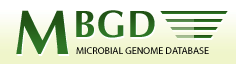<br>
MBGD is a database for comparative analysis of completely sequenced microbial genomes, the number of which is now growing rapidly. The aim of MBGD is to facilitate comparative genomics from various points of view such as ortholog identification, paralog clustering, motif analysis and gene order comparison. References: [J Mol Biol. 2025 Jan 16:168957](https://www.sciencedirect.com/science/article/pii/S0022283625000233)

In [ ]:
#@title Install dependencies
import os
import glob
def clone_repo(repo_url, repo_name):
    target_path = f"/content/{repo_name}"
    bin_path = f"{target_path}/bin"
    if not os.path.exists(target_path):
        !git clone {repo_url} {target_path}
    else:
        print(f"'{target_path}' already exists, skipping clone.")
    os.environ["PATH"] = f"{bin_path}:{os.environ['PATH']}"
    print(f"Added to PATH: {bin_path}")
def install_from_tar(download_url, binary_name, archive_name="temp.tar.gz", extract_dir="/content"):
    archive_path = f"/content/{archive_name}"
    if binary_name is None or str(binary_name).lower() == "none":
        print(f"Downloading and extracting to {extract_dir}...")
        !wget -q -P /content {download_url}
        !tar -xf {archive_path} -C {extract_dir}
        if os.path.exists(archive_path):
            !rm {archive_path}
        print(f"Successfully extracted archive to {extract_dir}")
    else:
        target_binary_path = f"/usr/local/bin/{binary_name}"

        if not os.path.exists(target_binary_path):
            !wget -q -P /content {download_url}
            !tar -xf {archive_path} -C /usr/local/bin

            if os.path.exists(archive_path):
                !rm {archive_path}
            print(f"Successfully installed '{binary_name}' to /usr/local/bin")
        else:
            print(f"'{target_binary_path}' already exists, skipping installation.")

clone_repo("https://github.com/mbgd-prj/domclust", "domclust")
clone_repo("https://github.com/mbgd-prj/mbgd-pipeline", "mbgd-pipeline")
%cd /content/domclust
!sh ./configure --prefix=/usr/local
!make install
%cd /content
install_from_tar("https://github.com/bbuchfink/diamond/releases/download/v2.2.5/diamond-linux64.tar.gz", "diamond", archive_name="diamond-linux64.tar.gz")
install_from_tar("https://mbgd.nibb.ac.jp/CGB/dist/CGB.tgz", "none", archive_name="CGB.tgz", extract_dir="/content")
!cp /content/CGB/lib/CompareMap.jar /content/mbgd-pipeline/lib/
!cp /content/CGB/bin/corealign /content/mbgd-pipeline/bin/
!apt update -qq
!apt install -y openjdk-11-jre xvfb libwww-perl libjson-perl
candidates = glob.glob("/usr/lib/jvm/java-11-openjdk-*/bin/java")
if not candidates:
    raise RuntimeError("Java 11 JRE not found")
JAVA = candidates[0]
print("Using Java:", JAVA)
os.system(f"{JAVA} -version")

# Step-by-step orhtology analysis using MBGD
Create a **bacillus** directory in your Google Drive's "My Drive" and work there.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!mkdir -p /content/drive/MyDrive/bacillus
%cd /content/drive/MyDrive/bacillus

## Download data from MBGD and format it as required
We will now perform clustering using data from four species of the genus Bacillus.

*   *Bacillus anthraci* : ban
*   *Bacillus cereus* : bce
*   *Bacillus subtilis* : bsu


In MBGD, each species is assigned a 3 to 5 letter code, which is used when downloading data from the MBGD API. <br>
You can look up the codes under "**Search for spid, taxid, etc.**" menu on the MBGD API toppage (https://mbgdapi.nibb.ac.jp).

In [ ]:
%%bash
mbgd2genetab.pl -outname=bacillus ban bce bsu

In [ ]:
!ls -l bacillus.faa bacillus.genetab

To run DomClust, you need a genetab file and a protein sequence file. <br>Let's look at the genetab file you have just downloaded.

In [ ]:
!head bacillus.genetab

Genetab file (.genetab) is a tab-delimited file that contains the following information for each gene:

       species_code  gene_id  proteinseq_length  [center_position] [direction]
Only the first 3 columns are mandatory for DomClust. The latter 2 are used by CoreAligner for synteny analysis. This genetab file also contains genome and chromosome information, which are also used by CoreAligner.

Protein sequence file should be in FASTA format.

In [ ]:
!head bacillus.faa

In the sequence file, each sequence name should be in the following format:

    >species_code:gene_id
i.e., the species code and sequence name should be joined with a colon.<br>
Note also that these names should be consistent with those in the genetab file.

## Add more genomes
In addition to published genomes in MBGD, users can analyze additioinal genomic data prepared by themselves. <br>Here, we will use a metagenome assembled genome (MAG) of putative Bacillus species (GCA_001884825.1) annotated using Prokka. <br>This data is included in the MBGD pipeline package.

In [ ]:
!cp -r /content/mbgd-pipeline/test_mag/UG00001 .
!ls UG00001

### The following scripts can be used to make a genetab file and a protein seuqne file.
 * **gff2genetab.pl**  converts a GFF file to a genetab file. Use -tag=_tagName_ option to specify from which tag in the last field of GFF the gene ID is taken.
 * **prepare_fastafile.pl** converts gene ID in the FASTA file into DomClust compatible form, i.e., sp_code:gene_id. Use -SPNAME=_spCode_ option to specify the species code.

In [ ]:
!gff2genetab.pl -tag=locus_tag UG00001/GCA_001884825.1.gff >UG00001.genetab
!prepare_fastafile.pl -SPNAME=UG00001 UG00001/GCA_001884825.1.faa > UG00001.faa

Please check species code and gene ID are correctly defined, i.e., consistent between the genetab file and the protein sequence file.<br>
If it is OK, add these files into the original genetab and protein sequence files.

In [ ]:
!head UG00001.genetab UG00001.faa

In [ ]:
!cat UG00001.genetab >> bacillus.genetab
!cat UG00001.faa >> bacillus.faa

## Execute diamond
Perform an all-against-all search across the query genomes using Diamond.

In [ ]:
!diamond makedb --in bacillus.faa --db bacillus

In [ ]:
!diamond blastp --query bacillus.faa --db bacillus --evalue 0.001 --out bacillus.diamondout

## Create a homfile from the diamond output file.
For DomClust, the output of Diamond (or output of any other similarity search program in BLAST tabular format) should be converted into an original format.<br> This script (blast2homfile.pl) is included in the DomClust package.

In [ ]:
!blast2homfile.pl bacillus.diamondout > bacillus.hom

In [ ]:
!head bacillus.hom

## Execute **domclust**
Now execute DomClust. Minimally, homology file and gentab file should be specified as operands.

In [ ]:
!domclust bacillus.hom bacillus.genetab | head

However, the default parameter setting of DomClust may not be recommended one. <br>The parameter setting used to construct the standard ortholog table in MBGD is included in a script ```exec_domclust.sh```, which is included in the MBGD pipeline.

In [ ]:
!cat /content/mbgd-pipeline/bin/exec_domclust.sh

In [ ]:
!exec_domclust.sh bacillus.hom bacillus.genetab > bacillus.domclust.o0
!head bacillus.domclust.o0

Output format can be changed by -o option. <br>For example, -o1 displays a hierarchical tree for each cluster, -o5 tab-delimited one line output for each cluster.

In [ ]:
!exec_domclust.sh -o5 bacillus.hom bacillus.genetab > bacillus.domclust.o5
!head bacillus.domclust.o5

Ths format (o5) is sutable for processing data, phylogenetic profile (presence or absence) analysis.

In [ ]:
import math
import pandas as pd

infile = "bacillus.domclust.o5"
df = pd.read_table(infile, sep='\t', index_col=0)
countmat = df.map(lambda x: len(x.split(' ')) if (not pd.isna(x)) else 0)
print("Count matrix")
print(countmat)

print("\nFilterd ortholog groups:\npresence: UG00001, absence: bce")
print(countmat.query('bce == 0 and UG00001 == 1'))

## Align core gene synteny using CoreAligner
For comparisons of closely related genomes, synteny analysis is particularly effective. <br>CoreAligner accepts DomClust output (in the default 'o0' format) and a genetab file in the extended format, and identifies syntenically conserved regions and the consensus order of orthologous genes within these regions.

In [ ]:
!/content/mbgd-pipeline/bin/corealign -domclustIn -out=bacillus.coaln bacillus.domclust.o0 bacillus.genetab

Ignore any warnings

In [ ]:
!head bacillus.coaln

## Visualize the synteny of core genes across genomes
If you do not specify -outfile, an interactive Java window will launch.<br>
However, since this is a Colab notebook, the Java window will not work

In [ ]:
!xvfb-run -a {JAVA} -jar /content/mbgd-pipeline/lib/CompareMap.jar bacillus.coaln bacillus.genetab -outfile=bacillus.png -center=bsu:0

In [ ]:
from IPython.display import Image, display
display(Image(filename="bacillus.png"))

#### Explore more with MBGD!

Visit **[MBGD](https://mbgd.genome.ad.jp/)** for more comparative genomics resources and tools.